-----
# AM10: Computing for Science and Engineering - Module 2

## Section 05
-----

### Learning objectives:

- Applications numerical differentiation: Derivatives of known and unknown (data) functions

- Applications Taylor expansion and propagation of values: Mass on spring

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Bacterial growth model

In the exercises below, we will apply the `central_diff` function we wrote in the lab towards a realistic problem. We will explore the population dynamics of bacteria. More specifically, we want to look at the ***growth rate*** of a specific bacterial population (or colony) as a function of time. 

A commonly used model to describe the growth of a bacterial colony is using a logistic-sigmoid function, for example:

$$n(t)=\frac{N}{1+\left[\frac{N}{n_0}-1\right]e^{-rt}} \hspace{6cm} (1)$$

You might recognize this form from the notes for lecture 4 (eq. 4.17). Here, $n$, represents the number of bacteria (or the size of the colony), $n_0$ is the bacterial population at $t=0$, $r$ represents their growth rate factor, and $N$ represents the total carrying capacity of the environment they are in (this is the upper limit to their population). The derivative of this function (eq 1) gives the rate of change of the number of bacteria over time, *i.e.* the growth rate. 

We also happen to have data from an experiment where the size of a bacterial colony was determined by taking images through a microscope every 45 minutes and measuring the radius of the colony. This data can be found in the file `AM10-Sec-05-bactdata.txt`.

Let's compute the growth rate from the model as well as the data and compare them!

### Exercise 1

Load the data from `AM10-Sec-05-bactdata.txt` and plot it. There are two columns in the file, the right (2nd) column contains the time while the left (1st) column contains the radius of a bacterial colony as measured at that time. Calculate the first derivative of the data, *i.e*, the measured growth rate of a bacterial colony as a function of time and plot it in a separate figure. Copy and use the function `central_diff` from the lab for the previous.

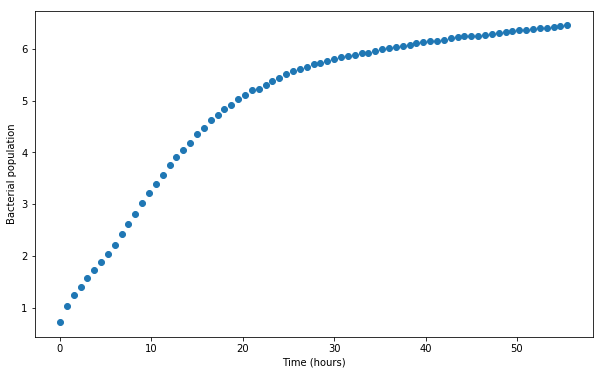

In [2]:
# Load data from file
data = np.loadtxt('AM10-Sec-05-bactdata.txt')
time = data[:, 1]
radius = data[:, 0]

# Plot the data 
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(time, radius, 'o')
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Bacterial population')
plt.show(fig1)

In [3]:
# The function central_diff from lab 05

def central_diff(fx, dx):   

    ''' This function calculates the numerical first derivative of an inputted function 
        in the form of a vector using the central difference formula.
        Input:
           fx : Discretized function [vector]
           dx : Resolution [scalar]
        Output: 
           d1_cent : First derivative of function using central difference [vector]. 
    '''

    # Find the size of inputted function fx
    nx = len(fx)
    
    # Initialize the output array to zeros with the same size as the inputted array
    d1_cent=np.zeros(nx)
    
    # Generate the central difference array at all points except the first and last
    for n in range (1, nx-1):
        d1_cent[n] = (fx[n+1] - fx[n-1]) / (2.0 * dx)
            
    # Improve end points by first-order extrapolation
    d1_cent[0] = 2 * d1_cent[1] - d1_cent[2]
    d1_cent[nx - 1] = 2 * d1_cent[nx - 2] - d1_cent[nx - 3]

    # return the output
    return d1_cent

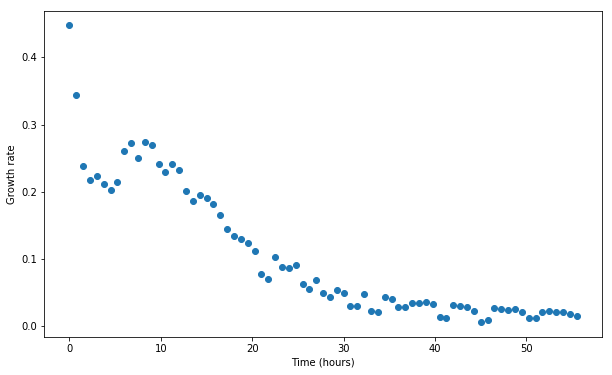

In [4]:
# Calculate dt from data
dt = time[1] - time[0]

# Calculate growth rate from data
gr = central_diff(radius, dt)

# Plot growth rate vs time
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(time, gr, 'o')
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('Growth rate')
plt.show(fig2)

### Exercise 2

Now calculate the growth rate from the logistic-sigmoid model (*i.e.* compute the first derivate of eq 1) in the same time range as the data (*i.e.* $0\le t\le 55.5$). Use $n_0=1.1684$, $r=0.1485$, and $N=6.2352$. (We have basically predertimed the values of these parameters using a fit to the data.) Also, use $dt=0.1$ hour. Note: you can define an Python function that evaluates eq 1. Now, plot the growth rate from the model as well as the date together in the same figure.

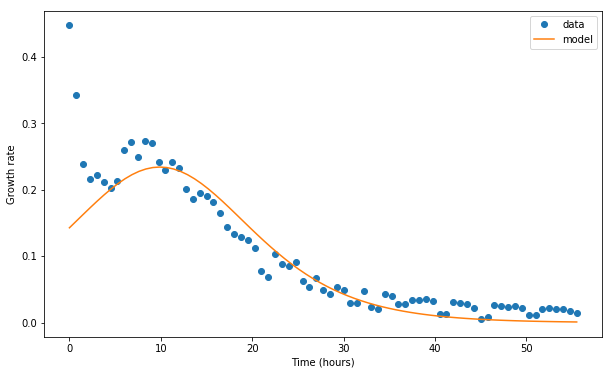

In [5]:
# Define constants
n0 = 1.1684
r = 0.1485
N = 6.2352

# generate the vector for time t
tmin = 0.0
tmax = 55.5
dx = 0.1
nt = int((tmax - tmin) / dt)
t = np.linspace(tmin, tmax, nt)

# Define n(t)
def noft(t, N, n0, r):
    n = N / (1 + (N / n0 - 1) * np.exp(-r * t))
    return n

# Evaluate n(t) to generate nt 
nt = noft(t, N, n0, r)

# Calculate growth rate
dndt = central_diff(nt, dt)

# Plot the model and data together
fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.plot(time, gr, 'o', label='data')
ax3.plot(t, dndt, label='model')
ax3.set_xlabel('Time (hours)')
ax3.set_ylabel('Growth rate')
ax3.legend()
plt.show(fig3)

### Falling object with time-dependent drag

From Lecture 5, you have seen how the Taylor expansion can be used to create an algorithm to propagate values and as a result solve a set of coupled ordinary differential equations. In the following exercises, we will apply the same algorithm to compute the accelaration, veloctiy, and position of an object falling with drag that is time-dependent.

As a reminder, $$v(t) = \frac{dx}{dt}, \; \; \; a(t) = \frac{dv}{dt} = \frac{d^2 x}{dt^2} $$ are the definitions of the velocity and accelaration. 

The force is given by, $$F = -mg + \frac{1}{2} \gamma(t) [v(t)]^2$$ where, $\gamma$ the damping coefficient has the following dependance on time. 

$\gamma(t) = \gamma_0 + k\sin{\omega t}$. 

### Exercise 3

Copy and modify the code from Lab 05 to compute and plot the position, velocity, and accelaration of the falling object. Use $\gamma_0=5$, $k=2$, $m=5$, and $\omega = 2\pi$. 

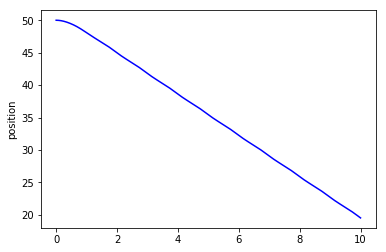

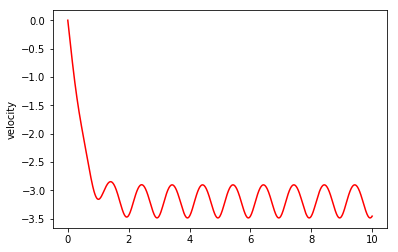

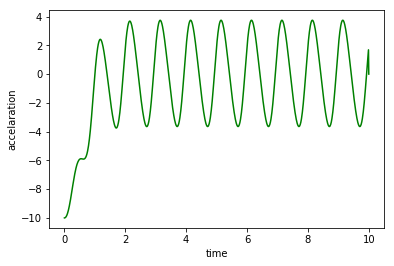

In [7]:
# Define constants
mass = 5.0
g = 10.0
gam0 = 5
k = 2
omeg = 2 * np.pi

# Define variables
tmax = 10
nt = 1000
t = np.linspace(0, tmax, nt)
dt = t[1]-t[0]
dt2 = dt**2

# Initialize variables
gamovm = np.zeros(nt)
gamovm = (gam0 + k * np.sin(omeg * t)) / mass
x = np.zeros(nt)
v = np.zeros(nt)
a = np.zeros(nt)

# Define initial conditions
x[0] = 50
v[0] = 0.0

# Loop for the time propagation of position, velocity, acceleration
for n in range(nt-1):
    # acceleration
    a[n] = -g + gamovm[n] * v[n]**2
    # position
    x[n+1] = x[n] + v[n] * dt + 0.5 * a[n] * dt2
    # velocity
    v[n+1] = (x[n+1] - x[n]) / dt

# Plot results
plt.plot(t, x, 'b')
plt.ylabel('position')
plt.show()
plt.plot(t, v, 'r')
plt.ylabel('velocity')
plt.show()
plt.plot(t, a, 'g')
plt.ylabel('accelaration')
plt.xlabel('time')
plt.show()

### Exercise 4

Say, you want to know when this object hits the groung ($x=0$). Use a `while` loop to allow time propagation as long as the position is non-negative. Use the same parameters as the previous problem. Print out the position, velocity, acceleration, and time after the loop exits. Also, plot the position, velocity, and acceleration as a function of time. 

At contact with ground:
position = -0.019080
velocity = -3.241152
acceleration = 3.724576
time = 16.140000


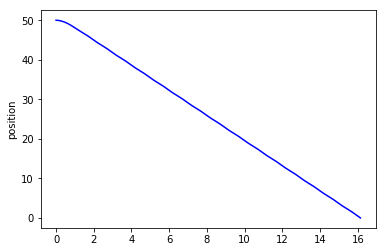

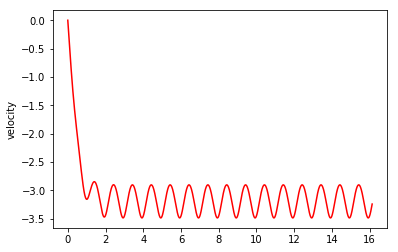

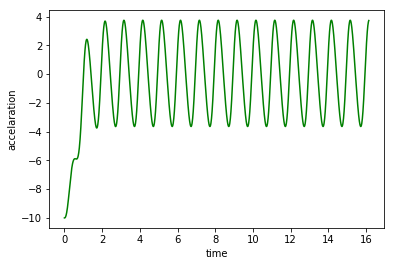

In [8]:
# Define constants
mass = 5.0
g = 10.0
gam0 = 5
k = 2
omeg = 2 * np.pi

# Define variables
dt = 0.01
dt2 = dt**2

# Define initial conditions
x0 = 50
v = 0.0
t = 0

# Define empty lists to hold variables
pos = [x0]
vel = [0]
acc = [-g]
time = [0]

# Loop for the time propagation of position, velocity, acceleration
n = 0
while x0 > 0:
    # update drag
    gamovm = (gam0 + k * np.sin(omeg * t)) / mass
    # acceleration
    a = -g + gamovm * v**2
    # position
    x1 = x0 + v * dt + 0.5 * a * dt2
    # velocity
    v = (x1 - x0) / dt
    # error
    err = np.absolute(a)
    # update position
    x0 = x1
    # update time
    t = t + dt
    # append lists
    acc.append(a)
    vel.append(v)
    pos.append(x1)
    time.append(t)

# Print out results
print('At contact with ground:')
print('position =', '{:f}'.format(x0))
print('velocity =', '{:f}'.format(v))
print('acceleration =', '{:f}'.format(a))
print('time =', '{:f}'.format(t))    

# Plot results
plt.plot(time, pos, 'b')
plt.ylabel('position')
plt.show()
plt.plot(time, vel, 'r')
plt.ylabel('velocity')
plt.show()
plt.plot(time, acc, 'g')
plt.ylabel('accelaration')
plt.xlabel('time')
plt.show()